In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
titanic_df = pd.read_csv("../data/titanic.csv")
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic_df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
titanic_df["age"] = titanic_df["age"].fillna(
    titanic_df["age"].median()
)

In [7]:
titanic_df.drop("deck", axis=1, inplace=True)

In [8]:
titanic_df["embarked"] = titanic_df["embarked"].fillna(
    titanic_df["embarked"].mode()[0]
)

In [9]:
titanic_df["embark_town"] = titanic_df["embark_town"].fillna(
    titanic_df["embark_town"].mode()[0]
)

In [10]:
titanic_df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [11]:
titanic_df.drop("alive", axis=1, inplace=True)

In [12]:
titanic_df[["pclass", "class"]].head()

,pclass,class
0,3,Third
1,1,First
2,3,Third
3,1,First
4,3,Third


In [13]:
titanic_df.drop("class", axis=1, inplace=True)

In [14]:
titanic_df[["embarked", "embark_town"]].head()

,embarked,embark_town
0,S,Southampton
1,C,Cherbourg
2,S,Southampton
3,S,Southampton
4,S,Southampton


In [15]:
titanic_df.drop("embark_town", axis=1, inplace=True)

In [16]:
titanic_df.drop("who", axis=1, inplace=True)

In [17]:
titanic_df.drop("adult_male", axis=1, inplace=True)

In [18]:
titanic_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'alone'],
      dtype='object')

In [19]:
titanic_df["sex"].unique()

array(['male', 'female'], dtype=object)

In [20]:
titanic_df["embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [21]:
titanic_df["alone"].unique()

array([False,  True])

In [22]:
titanic_df["sex"] = titanic_df["sex"].map({
    "male": 0,
    "female": 1
})

In [23]:
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,0,22.0,1,0,7.2500,S,False
1,1,1,1,38.0,1,0,71.2833,C,False
2,1,3,1,26.0,0,0,7.9250,S,True
3,1,1,1,35.0,1,0,53.1000,S,False
4,0,3,0,35.0,0,0,8.0500,S,True


In [24]:
titanic_df = pd.get_dummies(
    titanic_df,
    columns=["embarked"],
    drop_first=True
)

In [25]:
titanic_df["alone"] = titanic_df["alone"].astype(int)

In [26]:
titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,1,38.0,1,0,71.2833,0,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,0,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


In [27]:
X = titanic_df.drop("survived", axis=1)

y = titanic_df["survived"]

In [28]:
X.head()

,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,38.0,1,0,71.2833,0,False,False
2,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,35.0,1,0,53.1000,0,False,True
4,3,0,35.0,0,0,8.0500,1,False,True


In [29]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 9)
(179, 9)
(712,)
(179,)


In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [35]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
y_pred = dt_model.predict(X_test)

In [37]:
print(y_pred[:10])

[0 1 0 1 1 0 1 0 1 1]


In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7821229050279329


In [40]:
from sklearn.metrics import confusion_matrix

In [41]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[85, 20],
       [19, 55]])

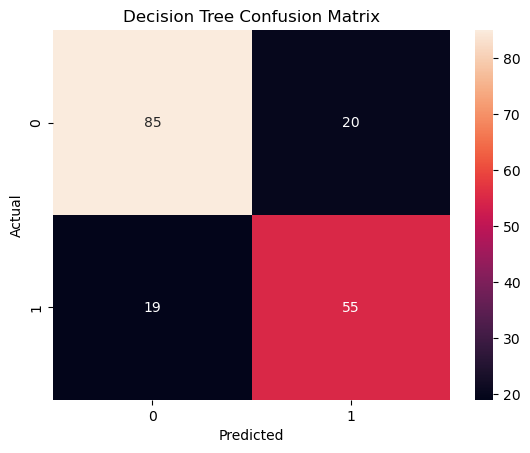

In [44]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
from sklearn.metrics import classification_report

In [46]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.81      0.81       105
           1       0.73      0.74      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



In [47]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance

,Feature,Importance
0,pclass,0.119347
1,sex,0.310280
2,age,0.199563
3,sibsp,0.058537
4,parch,0.013225
5,fare,0.270006
6,alone,0.006175
7,embarked_Q,0.004708
8,embarked_S,0.018158


In [48]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,sex,0.310280
5,fare,0.270006
2,age,0.199563
0,pclass,0.119347
3,sibsp,0.058537
8,embarked_S,0.018158
4,parch,0.013225
6,alone,0.006175
7,embarked_Q,0.004708


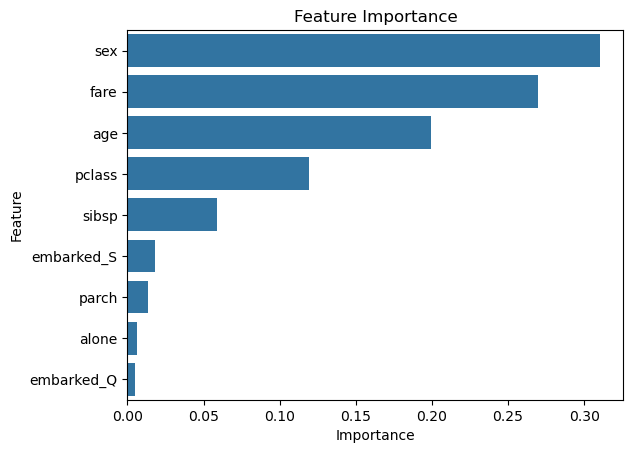

In [49]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()